# Лабораторная работа №1

In [577]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Описание датасета
Набор данных имитирует масштабное исследование с участием 100 000 студентов университетов, в ходе которого изучались их образ жизни, успеваемость и психическое состояние. 

- Student_ID - Уникальный идентификатор каждого студента
- Age - Возраст студента (18–24 года)
- Gender - Пол студента (мужской/женский)
- Department - Направление обучения (инженерное дело, бизнес, искусство и т. д.)
- CGPA - Средний балл успеваемости (от 0,0 до 4,0)
- Sleep_Duration - Среднее количество часов сна за ночь
- Study_Hours - Среднее количество часов, потраченных на учебу в день
- Social_Media_Hours - Среднее количество часов, потраченных на социальные сети в день
- Physical_Activity - Среднее количество минут физической активности в неделю
- Stress_Level - Самооценка уровня стресса (по шкале от 0 до 10)
- Depression - Состояние психического здоровья (True = вероятная депрессия, False = здоров)

## Загрузка датасета 
Загрузил датасет, удалил Student_ID, проверил тип данных и пропуски.

In [578]:
df = pd.read_csv('student_lifestyle_100k.csv')
df = df.drop('Student_ID', axis=1)
df.head(10)

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False
5,22,Female,Medical,3.31,6.5,3.5,4.1,129,2,False
6,18,Male,Science,2.14,4.4,4.0,3.1,73,8,True
7,18,Male,Engineering,3.27,7.0,3.4,7.6,68,4,False
8,21,Male,Business,2.71,4.8,8.6,0.3,82,5,False
9,24,Male,Engineering,3.36,5.7,1.5,3.7,59,3,False


In [579]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Age                 100000 non-null  int64  
 1   Gender              100000 non-null  str    
 2   Department          100000 non-null  str    
 3   CGPA                100000 non-null  float64
 4   Sleep_Duration      100000 non-null  float64
 5   Study_Hours         100000 non-null  float64
 6   Social_Media_Hours  100000 non-null  float64
 7   Physical_Activity   100000 non-null  int64  
 8   Stress_Level        100000 non-null  int64  
 9   Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(3), str(2)
memory usage: 7.0 MB


In [580]:
df.isna().sum()

Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

Пропусков нет


In [581]:
print(df.shape)
duplicates_rows = df[df.duplicated()]
print("Дубликаты:", duplicates_rows.shape)
df = df.drop_duplicates()
print("После удаления дубликатов:", df.shape)

(100000, 10)
Дубликаты: (0, 10)
После удаления дубликатов: (100000, 10)


Дубликатов тоже нет

## Анализ распределений
Визуализация всех признаков через гистрограммы и количетвенное представление по столбцам.

In [582]:
df.value_counts('Gender')

Gender
Male      50120
Female    49880
Name: count, dtype: int64

In [583]:
df.value_counts("Age")

Age
22    14462
24    14393
23    14285
19    14263
21    14207
18    14197
20    14193
Name: count, dtype: int64

In [584]:
df.value_counts("Department")

Department
Science        20071
Engineering    20057
Arts           19998
Medical        19964
Business       19910
Name: count, dtype: int64

In [585]:
df.value_counts("Depression")

Depression
False    89938
True     10062
Name: count, dtype: int64

In [586]:
df.value_counts("Stress_Level")

Stress_Level
5     24525
4     23326
3     22666
2     13591
6     11653
7      2255
8      1506
9       474
10        4
Name: count, dtype: int64

In [587]:
df['CGPA'].describe()

count    100000.000000
mean          2.898316
std           0.532240
min           1.560000
25%           2.450000
50%           2.900000
75%           3.350000
max           4.000000
Name: CGPA, dtype: float64

In [588]:
df["Sleep_Duration"].describe()

count    100000.000000
mean          6.996425
std           1.498682
min           3.000000
25%           6.000000
50%           7.000000
75%           8.000000
max          12.000000
Name: Sleep_Duration, dtype: float64

In [589]:
df['Physical_Activity'].describe()

count    100000.000000
mean         74.353180
std          43.366963
min           0.000000
25%          37.000000
50%          74.000000
75%         112.000000
max         149.000000
Name: Physical_Activity, dtype: float64

Увидел что есть студент который 149/168 часов в недели был физически активным - удивился. Далее понял, что это в минутах

In [590]:
plt.style.use('fivethirtyeight')

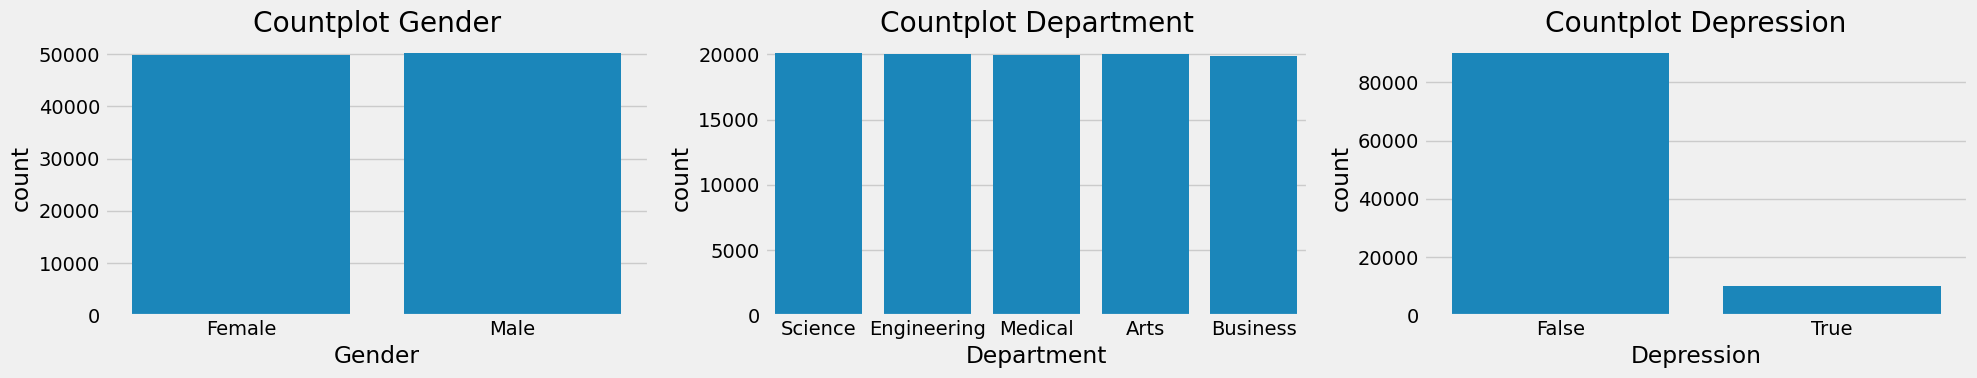

In [591]:
fig, axes = plt.subplots(1, 3,figsize=(20, 4))
sns.countplot(x=df['Gender'], ax=axes[0])
axes[0].set_title('Countplot Gender')
sns.countplot(x=df['Department'], ax=axes[1])
axes[1].set_title('Countplot Department')
sns.countplot(x=df['Depression'], ax=axes[2])
axes[2].set_title('Countplot Depression')
plt.tight_layout()
plt.show()

У признака `Depression` обнаружен сильный дисбаланс классов: абсолютное большинство студентов не обладают депрессией.


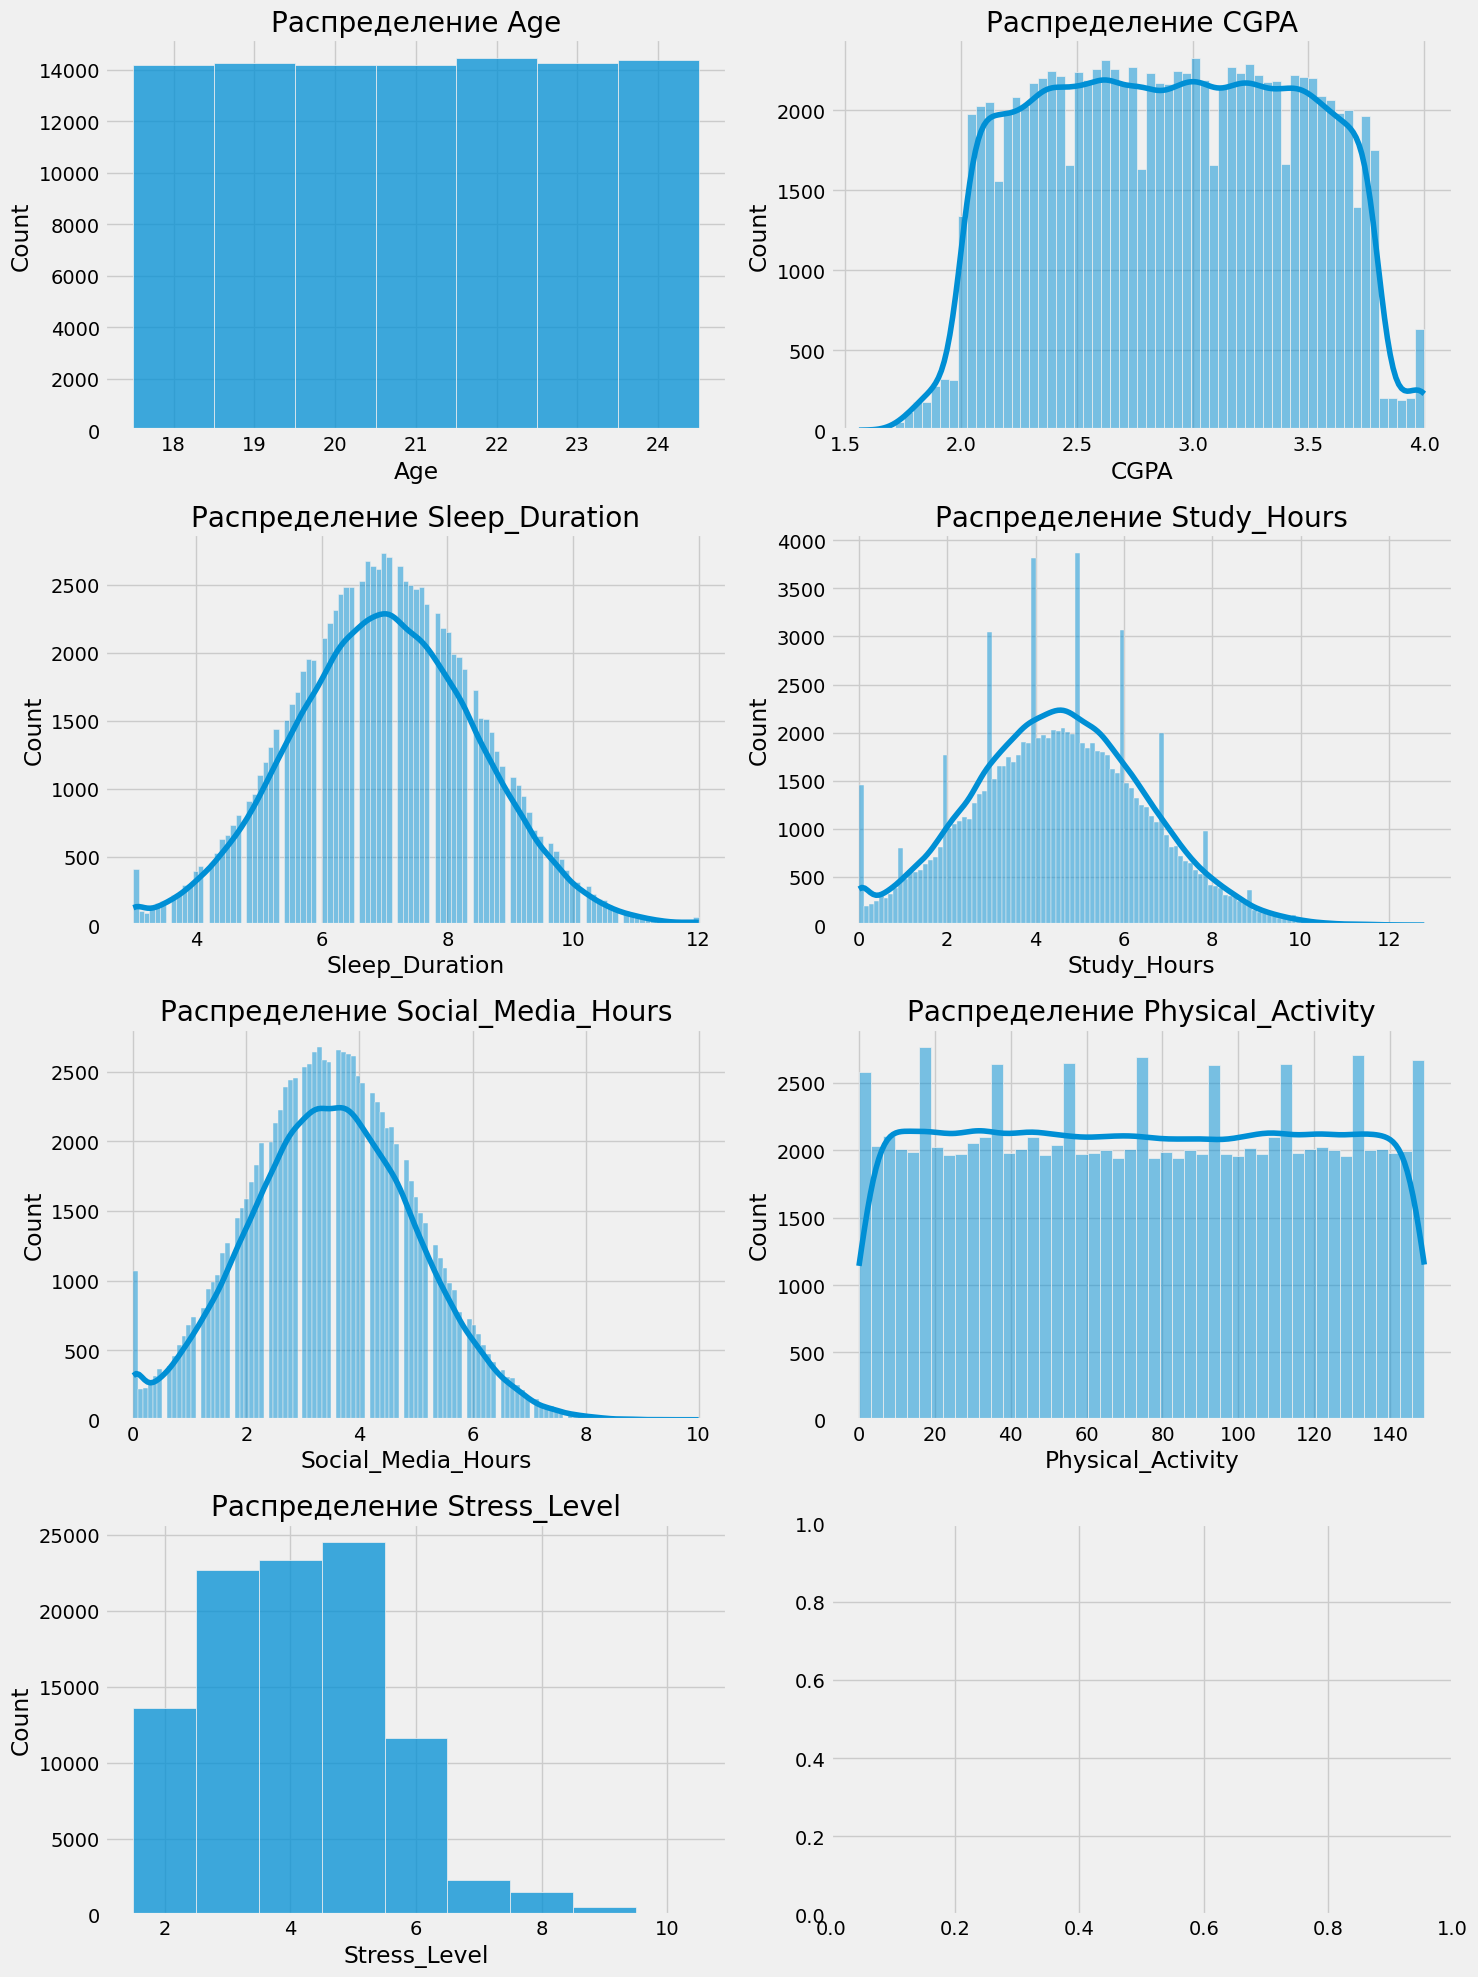

In [592]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
sns.histplot(df['Age'], kde=False, ax=axes[0, 0], discrete=True)
axes[0, 0].set_title('Распределение Age')
sns.histplot(df['CGPA'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Распределение CGPA')
sns.histplot(df['Sleep_Duration'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Распределение Sleep_Duration')
sns.histplot(df['Study_Hours'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Распределение Study_Hours')
sns.histplot(df['Social_Media_Hours'], kde=True, ax=axes[2, 0])
axes[2, 0].set_title('Распределение Social_Media_Hours')
sns.histplot(df['Physical_Activity'], kde=True, ax=axes[2, 1])
axes[2, 1].set_title('Распределение Physical_Activity')
sns.histplot(df['Stress_Level'], ax=axes[3, 0], discrete=True)
axes[3, 0].set_title('Распределение Stress_Level')
plt.tight_layout()
plt.show()



Признаки связанные с режимом дня имеют нормальное распределение, но у признака `Study_Hours` имеются длинные хвосты, эти значени не выглядят, как ошибки. У признака `Age` равномерное распределение, представлены студенты всех возрастов. Большинство студентов находяться в состоянии умеренного стресса <=6. Распределение `Physical_Activity` похоже на равномерное.


Text(0.5, 1.0, 'Распределение CGPA')

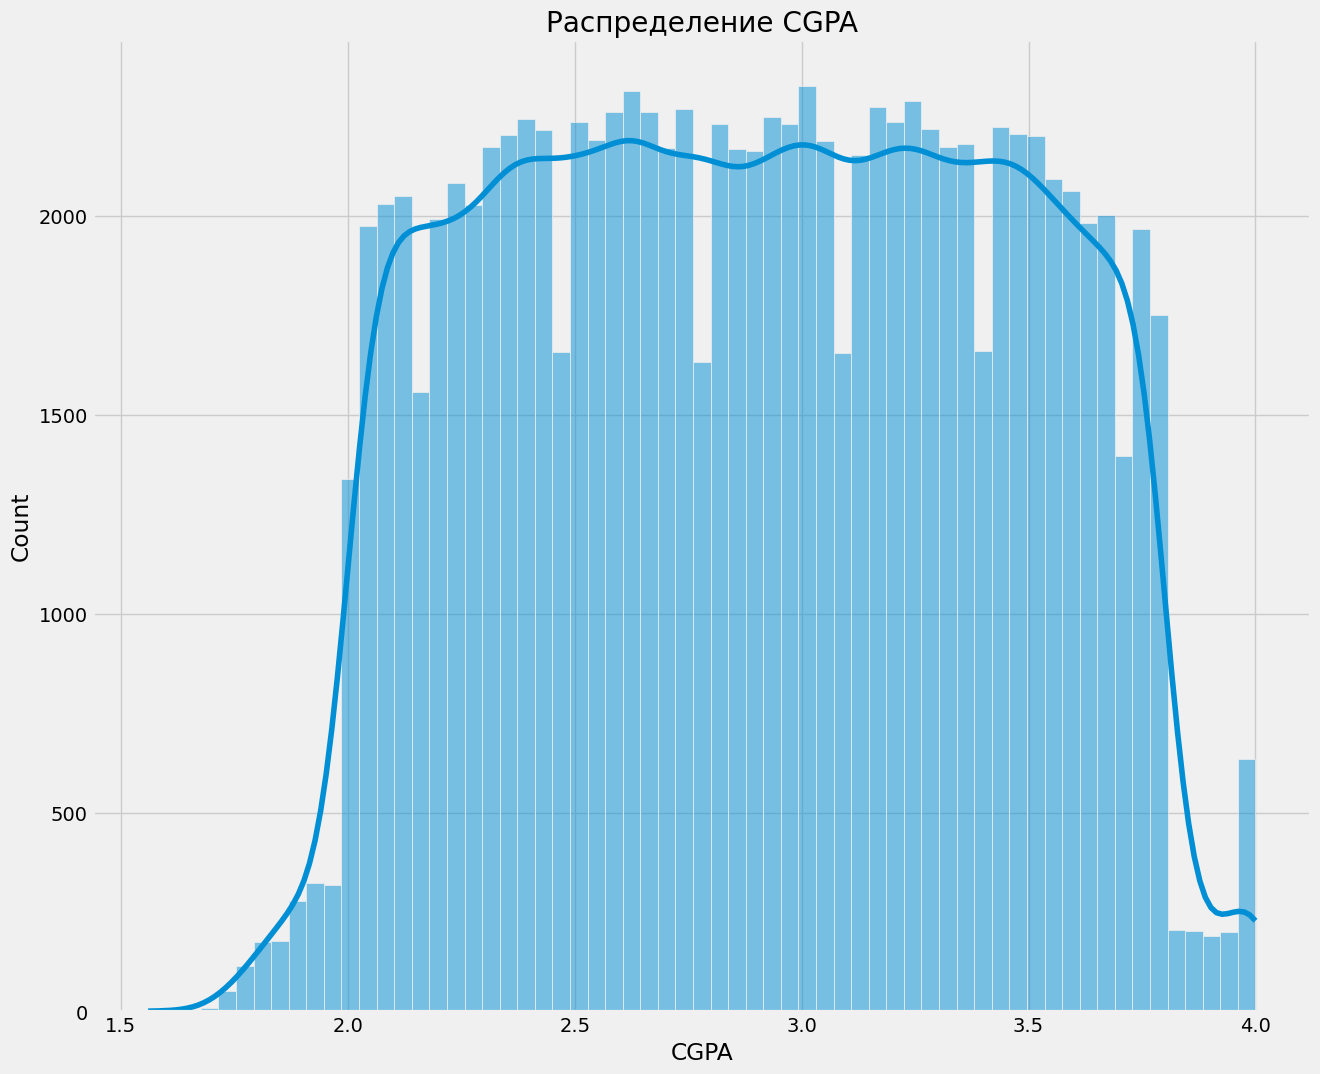

In [593]:
plt.figure(figsize=(14, 12))
sns.histplot(df['CGPA'], kde=True)
plt.title('Распределение CGPA')

Большинство студентов имеют успеваемость 2.0 - 3.8. Также существует небольшая группа студентов с крайне низкой успеваемостью.

## Поиск выбросов
Построил ящики с усами для числовых признаков

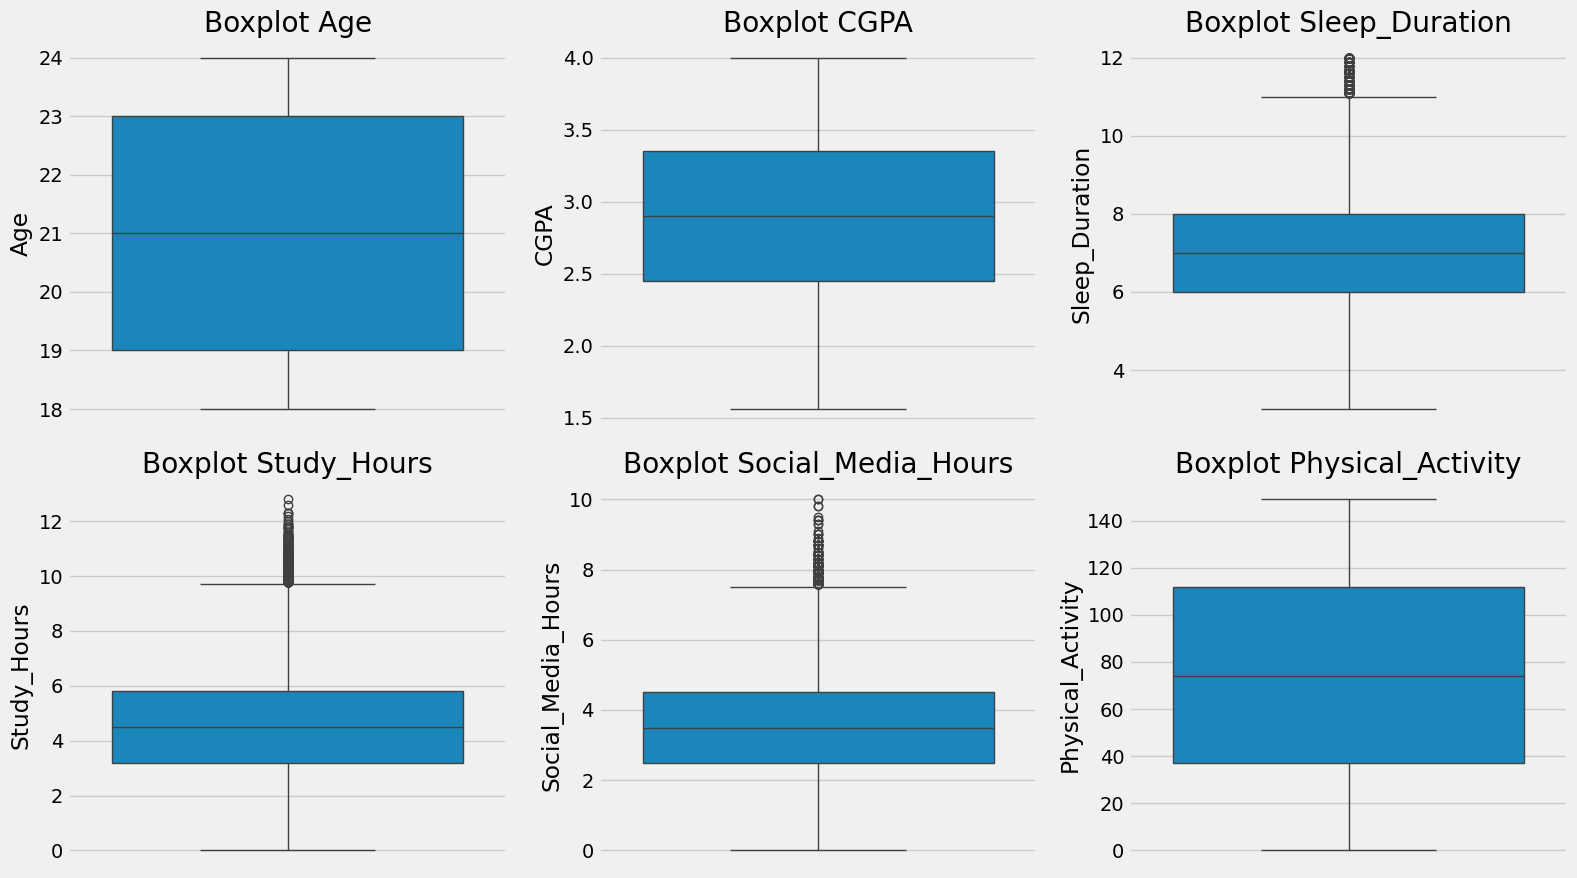

In [594]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))
sns.boxplot(df['Age'], ax=axes[0, 0])
axes[0,0].set_title('Boxplot Age')
sns.boxplot(df['CGPA'], ax=axes[0, 1])
axes[0,1].set_title('Boxplot CGPA')
sns.boxplot(df['Sleep_Duration'], ax=axes[0, 2])
axes[0,2].set_title('Boxplot Sleep_Duration')
sns.boxplot(df['Study_Hours'], ax=axes[1, 0])
axes[1,0].set_title('Boxplot Study_Hours')
sns.boxplot(df['Social_Media_Hours'], ax=axes[1, 1])
axes[1,1].set_title('Boxplot Social_Media_Hours')
sns.boxplot(df['Physical_Activity'], ax=axes[1, 2])
axes[1,2].set_title('Boxplot Physical_Activity')
plt.tight_layout()
plt.show()

Выбросов нет, есть только длинные хвосты. Значения признаков не являются ошибочными
Хвост у Study_hours сильнее всего связан с CGPA
Хвост у Social_Media_hours сильнее всего связан с депрессией

## Предобработка признаков
Провел кодирование категориальных признаков: для `Depression` и `Gender` применил замену на 0/1, для признака `Department` One-hot encoding

In [595]:
df['Depression'] = df['Depression'].astype(np.int64)
df['Gender'] = [1 if x == 'Male' else 0 for x in df['Gender']]
df = pd.get_dummies(df, columns=['Department'], drop_first=True)
for col in ['Department_Business', 'Department_Engineering', 'Department_Medical', 'Department_Science']:
    df[col] = df[col].astype(np.int64)
df.head()

,Age,Gender,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Department_Business,Department_Engineering,Department_Medical,Department_Science
0,22,0,3.50,7.3,3.3,3.4,114,5,0,0,0,0,1
1,20,1,2.72,5.5,7.2,6.0,142,2,0,0,1,0,0
2,20,1,3.01,5.4,2.3,1.8,137,3,0,0,0,1,0
3,21,1,3.63,8.1,2.0,4.6,130,3,0,0,1,0,0
4,19,1,3.14,6.8,2.6,4.3,4,6,0,0,0,0,0


Удалил колонку `Arts`, чтобы избежать мультиколлениарности


In [596]:
df.dtypes

Age                         int64
Gender                      int64
CGPA                      float64
Sleep_Duration            float64
Study_Hours               float64
Social_Media_Hours        float64
Physical_Activity           int64
Stress_Level                int64
Depression                  int64
Department_Business         int64
Department_Engineering      int64
Department_Medical          int64
Department_Science          int64
dtype: object

In [597]:
df['Total_Hours'] = df['Sleep_Duration']+ df['Study_Hours'] + df['Social_Media_Hours']
invalid_hours = df[df['Total_Hours'] > 24]
print(invalid_hours['Total_Hours'])

1228     25.2
2222     25.7
2524     24.1
2574     26.1
5050     24.6
         ... 
91644    24.2
93268    24.1
97322    25.4
97524    25.8
99510    24.3
Name: Total_Hours, Length: 79, dtype: float64


Нашел студентов, у которых за сутки получилось больше 24 часов потраченного времени, считаю правильным удалить такие данные.

In [598]:
df = df.drop(invalid_hours.index)
df = df.drop('Total_Hours', axis=1)

## Матрица корреляций
Построил матрицу корреляций

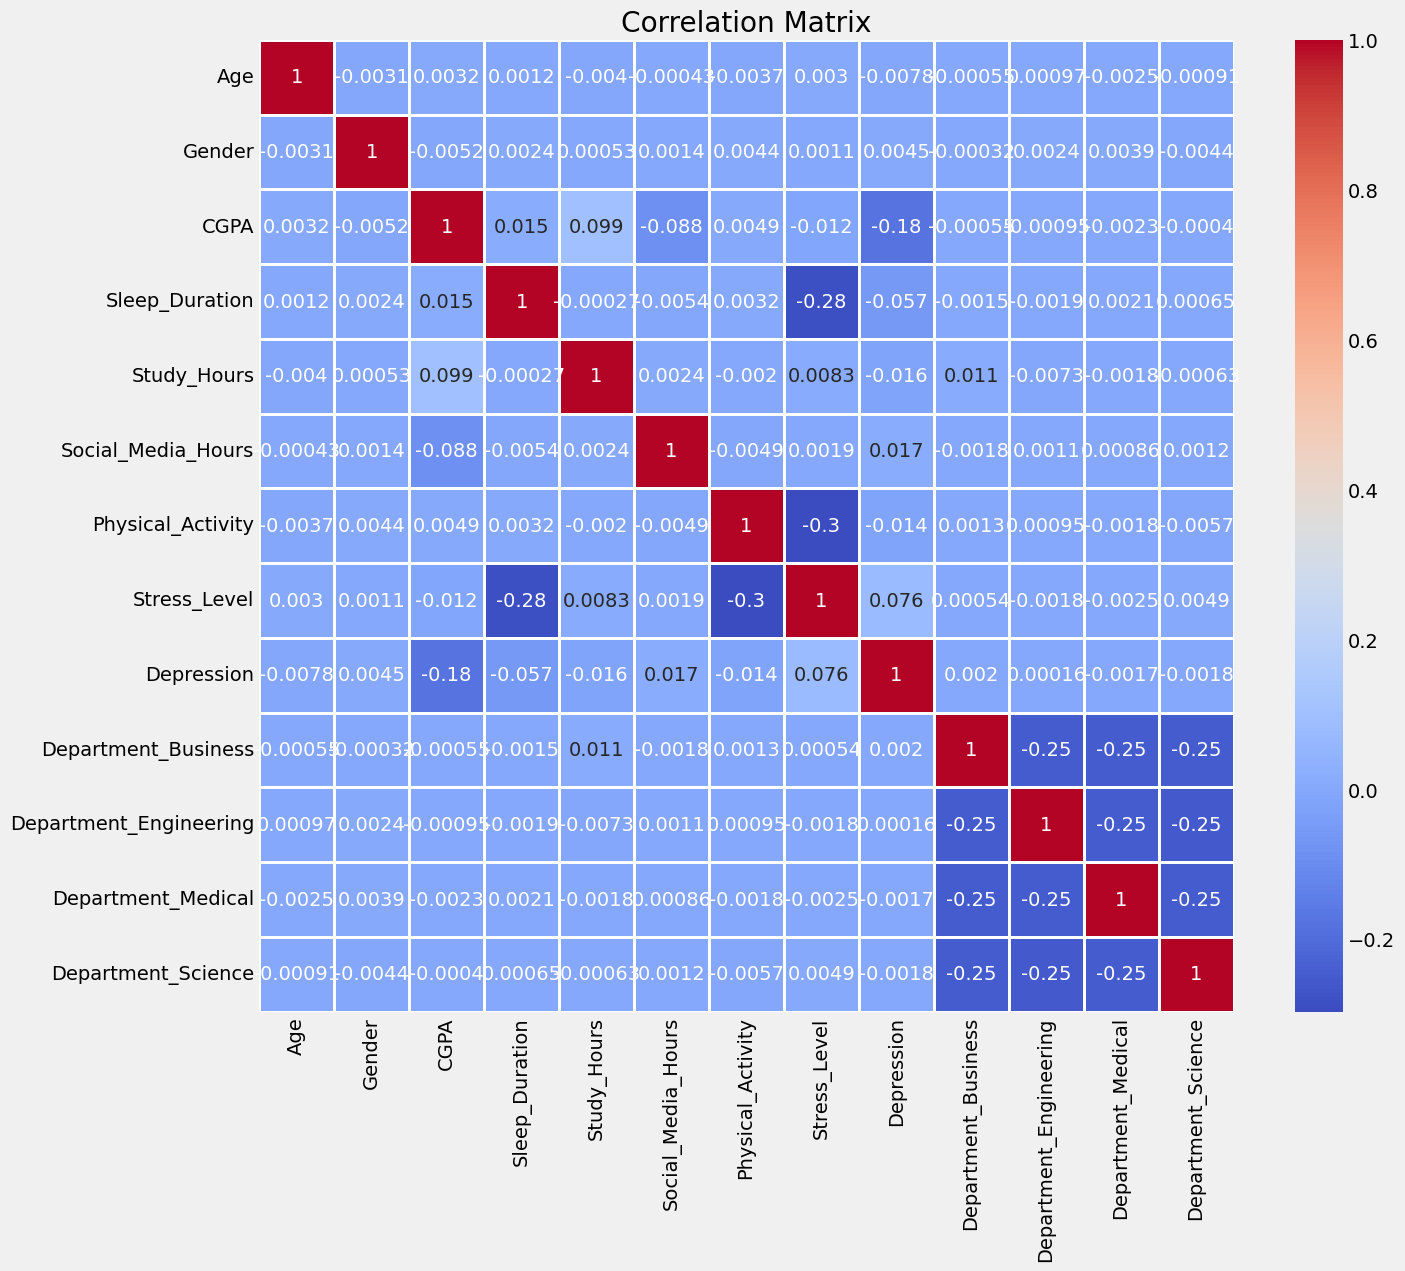

In [599]:
plt.figure(figsize=(14, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=2)
plt.title('Correlation Matrix')
plt.show()

### Отобор релевантных признаков и Feature Engineering
Для построения моделей будут отобраны признаки, указанные в техническом задании: Sleep_Duration, Study_Hours, Stress_Level, Social_Media_Hours и Physical_Activity. Выбор данных параметров обоснован их логической связью с состоянием студента: физиологическая (сон, активность) и когнитивная нагрузка (учеба, соцсети).

## Разделение данных на обучающую, валидационную и тестовую выборки

In [600]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.2, random_state=67)
df_train, df_validate = train_test_split(df_train, test_size=0.25, random_state=67)

df.shape, df_train.shape, df_validate.shape, df_test.shape

((99921, 13), (59952, 13), (19984, 13), (19985, 13))

## Линейная регрессия для CGPA

In [601]:
x_train_lin = df_train[['Sleep_Duration', 'Study_Hours']]
y_train_lin = df_train['CGPA']

x_test_lin = df_test[['Sleep_Duration', 'Study_Hours']]
y_test_lin = df_test['CGPA']
x_validate_lin = df_validate[['Sleep_Duration', 'Study_Hours']]
y_validate_lin = df_validate['CGPA']

x_train_lin.head()





,Sleep_Duration,Study_Hours
18359,8.7,4.1
97421,5.8,1.7
10827,7.5,1.7
10110,6.5,3.5
15170,7.9,3.1


### Масштабирование признаков

In [602]:
from sklearn.preprocessing import StandardScaler
scaler_lin = StandardScaler()
x_train_scaled = scaler_lin.fit_transform(x_train_lin)
x_test_scaled = scaler_lin.transform(x_test_lin)
x_validate_scaled = scaler_lin.transform(x_validate_lin)

x_train_scaled[:5]

array([[ 1.13749346, -0.20992323],
       [-0.79869254, -1.42460982],
       [ 0.33631305, -1.42460982],
       [-0.3313373 , -0.51359487],
       [ 0.60337319, -0.71604264]])

### Модель линейной регрессии 

In [603]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(x_train_scaled, y_train_lin)

y_validate_pred = lin_model.predict(x_validate_scaled)

pd.Series(lin_model.coef_, index=x_train_lin.columns).sort_values(ascending=False)

Study_Hours       0.052508
Sleep_Duration    0.008530
dtype: float64

`CGPA` слабо коррелирует с `Study_Hours` -  0.052508 и `Sleep_Duration` -  0.008530. Но все-таки оба признака положительно коррелируют с успеваемостью, влияние времени учебы почти в 7 раз больше влияния продолжительности сна, поэтому признак `Study_Hours` наиболее влияющий признак на `CGPA`.

In [604]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_model = mean_absolute_error(y_validate_lin, y_validate_pred)

y_naive_pred = np.full(y_validate_lin.shape, y_train_lin.mean())
mae_naive = mean_absolute_error(y_validate_lin, y_naive_pred)

model_r2 = r2_score(y_validate_lin, y_validate_pred)
print('MAE модели:', mae_model)
print('MAE наивной модели:', mae_naive)
print('Соотношение MAE:', mae_naive/mae_model)
print('R^2:', model_r2)

MAE модели: 0.45711192117921595
MAE наивной модели: 0.45858365896079556
Соотношение MAE: 1.0032196442783268
R^2: 0.01000519607818462


MAE модели чуть лучше (на 0.3%) MAE наивного прогноза успеваемости. Прирост точности отсутсвует при использовании признаков `Study_Hours` и `Sleep_Duration`. Значение `R^2` практически нулевое, что подвтверждает: выбранные признаки никак не объясняют разброс успеваемости. Линейная зависимость между признаками и целью отсутвует. Линейная модель слабо обучаема для предсказывания `CGPA`. `Study_Hours` и `Sleep_Duration` не являются значимыми факторами для точного предсказывания `CGPA`.

## Логистическая регрессия


In [605]:
x_train = df_train[['Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Sleep_Duration', 'Stress_Level']]
y_train = df_train['Depression']

x_test = df_test[['Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Sleep_Duration', 'Stress_Level']]
y_test = df_test['Depression']

x_validate = df_validate[['Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Sleep_Duration', 'Stress_Level']]
y_validate = df_validate['Depression']

x_train.head()

,Study_Hours,Social_Media_Hours,Physical_Activity,Sleep_Duration,Stress_Level
18359,4.1,4.9,141,8.7,3
97421,1.7,0.0,117,5.8,5
10827,1.7,3.9,145,7.5,5
10110,3.5,3.0,25,6.5,5
15170,3.1,2.8,126,7.9,3


### Масштабирование признаков

In [606]:
from sklearn.preprocessing import StandardScaler

scaler_log = StandardScaler()
x_train_scaled = scaler_log.fit_transform(x_train)
x_test_scaled = scaler_log.transform(x_test)
x_validate_scaled = scaler_log.transform(x_validate)

x_train_scaled[:5]

array([[-0.20992323,  0.94197686,  1.53300394,  1.13749346, -0.79107092],
       [-1.42460982, -2.36151901,  0.97965567, -0.79869254,  0.61408985],
       [-1.42460982,  0.26779403,  1.62522865,  0.33631305,  0.61408985],
       [-0.51359487, -0.33897052, -1.14151271, -0.3313373 ,  0.61408985],
       [-0.71604264, -0.47380708,  1.18716127,  0.60337319, -0.79107092]])

### Модель логистической регрессии


In [607]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

c_value = [0.001, 0.01, 0.1, 1, 10, 100]
iterations = [100, 200, 500, 1000]

max_acc = 0
min_acc = 1
best_model = None
least_model = None
for c in c_value:
    for iter in iterations:
        model = LogisticRegression(C=c, max_iter=iter, class_weight='balanced', random_state=67)
        model.fit(x_train_scaled, y_train)
        y_validate_pred = model.predict(x_validate_scaled)
        acc = accuracy_score(y_validate, y_validate_pred)
        print(f"C={c}, max_iter={iter}, Accuracy={acc}")
        if acc > max_acc:
            max_acc = acc
            best_model = model
        elif acc < min_acc:
            min_acc = acc
            least_model = model

print(f'Лучшая модель: C={best_model.__dict__["C"]}, max_iter={best_model.__dict__["max_iter"]}, Accuracy={max_acc}')
print(f'Худшая модель: C={least_model.__dict__["C"]}, max_iter={least_model.__dict__["max_iter"]}, Accuracy={min_acc}')

C=0.001, max_iter=100, Accuracy=0.5732586068855084
C=0.001, max_iter=200, Accuracy=0.5732586068855084
C=0.001, max_iter=500, Accuracy=0.5732586068855084
C=0.001, max_iter=1000, Accuracy=0.5732586068855084
C=0.01, max_iter=100, Accuracy=0.5730084067253803
C=0.01, max_iter=200, Accuracy=0.5730084067253803
C=0.01, max_iter=500, Accuracy=0.5730084067253803
C=0.01, max_iter=1000, Accuracy=0.5730084067253803
C=0.1, max_iter=100, Accuracy=0.573308646917534
C=0.1, max_iter=200, Accuracy=0.573308646917534
C=0.1, max_iter=500, Accuracy=0.573308646917534
C=0.1, max_iter=1000, Accuracy=0.573308646917534
C=1, max_iter=100, Accuracy=0.573308646917534
C=1, max_iter=200, Accuracy=0.573308646917534
C=1, max_iter=500, Accuracy=0.573308646917534
C=1, max_iter=1000, Accuracy=0.573308646917534
C=10, max_iter=100, Accuracy=0.573308646917534
C=10, max_iter=200, Accuracy=0.573308646917534
C=10, max_iter=500, Accuracy=0.573308646917534
C=10, max_iter=1000, Accuracy=0.573308646917534
C=100, max_iter=100, Accura

Перебрал различные значения параметра регуляризации `C`(мне показалось этот параметр похожим на параметр шага обучения из условия тз) и количества итераций(шагов) `max_iter`. Нашел лучшую и худшую модели относительно процента правильных предсказываний от общего числа.

In [608]:
best_model.fit(x_train_scaled, y_train)

y_validate_pred_best = best_model.predict(x_validate_scaled)

pd.Series(best_model.coef_[0], index=x_train.columns).sort_values(ascending=False)


Stress_Level          0.164339
Social_Media_Hours    0.043628
Physical_Activity    -0.000552
Study_Hours          -0.055750
Sleep_Duration       -0.096474
dtype: float64

In [609]:
least_model.fit(x_train_scaled, y_train)

y_validate_pred_least = least_model.predict(x_validate_scaled)

pd.Series(least_model.coef_[0], index=x_train.columns).sort_values(ascending=False)


Stress_Level          0.163493
Social_Media_Hours    0.043343
Physical_Activity    -0.000816
Study_Hours          -0.055382
Sleep_Duration       -0.096235
dtype: float64

У лучшей модели коэфициенты всех признаков по модулю оказлись выше, предполагаю, что этим и вызвано повышение точности модели.


`Depression` сильнее всего коррелирует с `Stress_Level` (0.163493), `Social_Media_Hours` коррелирует слабо (0.043343). Эти признаки повышают риск депресии. `Sleep_Duration` (-0.096235) и `Study_Hours` ( -0.055382) коррелируют слабо отрицательно, отрицательная корреляция делает эти признаки понижающими риск депресии. У `Physical_Activity` (-0.000816) влияние почти нулевое, практически не коррелирует с риском депрессии.

[[10423  7512]
 [ 1015  1034]] 

               precision    recall  f1-score   support

No Depression       0.91      0.58      0.71     17935
   Depression       0.12      0.50      0.20      2049

     accuracy                           0.57     19984
    macro avg       0.52      0.54      0.45     19984
 weighted avg       0.83      0.57      0.66     19984



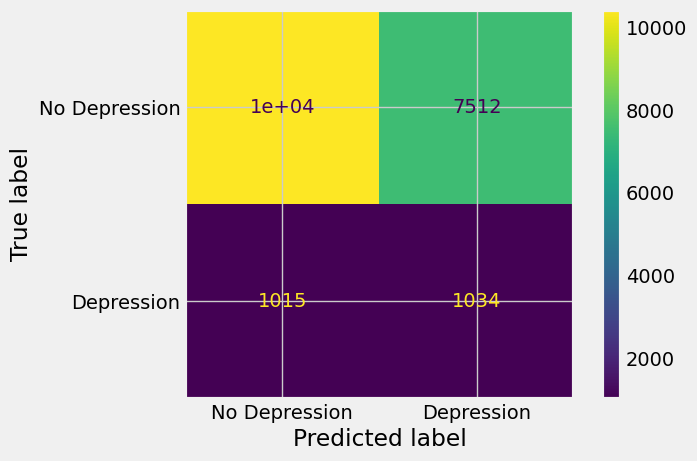

In [610]:
from sklearn.metrics import classification_report,  confusion_matrix, ConfusionMatrixDisplay

conf_matrix = confusion_matrix(y_validate, y_validate_pred_best)
print(conf_matrix, "\n")
print(classification_report(y_validate, y_validate_pred_best, target_names=['No Depression', 'Depression']))
ConfusionMatrixDisplay(conf_matrix, display_labels=['No Depression', 'Depression']).plot()

### Confusion Matrix:

- 10423 здоровых и модель сказала что они здоровы.
- 7512 здоровых модель посчитала больными.
- 1015 больных, а модель сказала что они здоровы.
- 1034 больныъ и модель сказала что они больны.



### Classification Report:

- `precision`(точность) -  значит, что из 100 человек, которых модель назвала больными, реально больны только 12.
- `recall` (полнота) - значит, из всех реальных случаев деперсии нашла 0.50.
- `f1-score` - среднее гармоническое между точностью и полнотой, золотая середина.
- `support` - количество людей в валидационной выборке (17935 здоровых и 2049 с риском).
- `accuracy` -  общий процент точности от всех данных.


По логистической модели можно сказать следующее: точность предсказывания 57% выше на 7% чем случайное угадывание 50%. Низкое значение f1-score говорит о том, что модель не готова полностью принимать решение, ошибается в обе стороны. Но модель находит половину 50% реальных студентов с депрессией, хоть и совершает большое количество ложных предположений о депрессии.

### Отсутствие переобучения:
Отсутствие переобучения в логистической регрессии доказывается стабильностью метрик. В ходе экспериментов с параметром C (регуляризацией) точность на валидационной выборке не падала, а зафиксировалась на одном уровне (57%). Использование C=0.1 ограничило рост весов признаков, не давая модели заучивать тренировочный набор. То, что результаты на валидационной выборке стабильны и предсказуемы подтверждает, что модель выявила общие закономерности, а не подстроилась под шум в данных.

## Общие выводы

### Влияние предобработки:
Я считаю, что удаление аномальных данных позволило моделям работать без стабильнее, сделав признаки стабильнее. Масштабирование уравняло значимость каждого признака, без масштабирования колонки с большИми значениями подавили бы другие признаки.

### Качество моделей:
Линейная регрессия показала слабые результаты, коэфициенты корреляции были довольно низкими. Логистическая модель оказалась эффективнее при точности 57% находит 50% реально студентов с депрессией 


## Я :)

In [611]:
df.columns

Index(['Age', 'Gender', 'CGPA', 'Sleep_Duration', 'Study_Hours',
       'Social_Media_Hours', 'Physical_Activity', 'Stress_Level', 'Depression',
       'Department_Business', 'Department_Engineering', 'Department_Medical',
       'Department_Science'],
      dtype='str')

In [612]:
me = pd.DataFrame([[18, 1, 4.1 * 0.8, 7, 4, 3, 145, 5, 0, 0, 1, 0, 0]], columns=df.columns, index=['me'])
my_data_lin = pd.DataFrame([[7,4]], columns=['Sleep_Duration', 'Study_Hours'])
my_data_log = pd.DataFrame([[4, 3, 145, 7, 5]], columns=['Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Sleep_Duration', 'Stress_Level'])

In [613]:

my_data_lin_scaled = scaler_lin.transform(my_data_lin)
my_cgpa = lin_model.predict(my_data_lin_scaled)
print(f"CGPA: {my_cgpa[0]:.2f}")

CGPA: 2.88


In [614]:
my_data_log_scaled = scaler_log.transform(my_data_log)
my_depression = best_model.predict(scaler_log.transform(my_data_log))

status = "Есть риск" if my_depression[0] == 1 else "Риска нет"
print(f"Депрессия: {status}")

Депрессия: Есть риск


CGPA меньше на 0,4, депрессия не угадана